Script per provare la classe definita per l'analisi e la valutazione dei diversi keygenes.   


# Packages

In [16]:
import pandas as pd 

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # Nasconde i FutureWarning

# Per aggiungere un path per dei pacchetti selfmade
import sys
sys.path.append('__HandmadePackages__')

# Classe per agevolare la valutazione della performance di un subset di keygenes
from EvaluatePipeline import Evaluate

# Funzioni selfmade per preprocessing
import preprocessing
from evaluate_performance import performance_binary, performance_multiclass
# Classe selfmade per creare report LaTeX
#from LaTeX import LaTeX, knit

# Manage the data

## Import the data

In [17]:
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_DEGS_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_DEGREE_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Dottorato/TEPs HC vs GBM/Train_GSE68086_Test_GSE156902/Data Product/normalizedcounts_trained_onGSE68086_GBM_HC_BETWEENNESS.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_CLOSENESS_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_CLOSENESS_last5_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_EIGEN_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_CLUSTER_normalized_counts_train.csv")

df_train = pd.read_csv("train_data_new.csv")

print(f"df_train shape: {df_train.shape}")

#df_test1 = pd.read_csv("/Users/mattia/Desktop/Università/Dottorato/TEPs HC vs GBM/Train_GSE68086_Test_GSE156902/Data Product/testdata_normalized_GSE156902_GBM_HC.csv")
df_test1 = pd.read_csv("test.csv")

print(f"df_test1 shape: {df_test1.shape}")

df_train shape: (95, 121)
df_test1 shape: (322, 121)


In [18]:
#df_train = pd.read_csv("test.csv")

#print(f"df_train shape: {df_train.shape}")

#df_test1 = pd.read_csv("train_data_new.csv")
#print(f"df_test1 shape: {df_test1.shape}")

In [19]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

# ============================================================
# 1. Separazione features e label
# ============================================================
# df_train e df_test1 si assumono già caricati (es. da CSV)
# df_train = pd.read_csv("train.csv")
# df_test1 = pd.read_csv("test.csv")

X_train = df_train.iloc[:, :-1]   # tutte le colonne tranne l'ultima
y_train = df_train.iloc[:, -1]    # ultima colonna come target

X_test = df_test1.iloc[:, :-1]
y_test = df_test1.iloc[:, -1]

# ============================================================
# 2. LOGISTIC REGRESSION
# ============================================================
model_lr = LogisticRegression()

# Addestramento
model_lr.fit(X_train, y_train)

# Predizione
y_pred_lr = model_lr.predict(X_test)

print("######### RISULTATI LOGISTIC REGRESSION ######")
risultati_lr = performance_binary(
    test_y=y_test,
    predizioni=y_pred_lr,
    verbose=True,
    labels_float={"0": "Cancer", "1": "Healthy"}
)

# ============================================================
# 3. SVC "semplice"
# ============================================================
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale')

svc_model.fit(X_train, y_train)
y_pred_svc_simple = svc_model.predict(X_test)

print("######### RISULTATI SVC ######")
risultati_lr = performance_binary(
    test_y=y_test,
    predizioni=y_pred_svc_simple,
    verbose=True,
    labels_float={"0": "Cancer", "1": "Healthy"}
)

# ============================================================
# 4. RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("######### RISULTATI RF ######")
risultati_lr = performance_binary(
    test_y=y_test,
    predizioni=y_pred_rf,
    verbose=True,
    labels_float={"0": "Cancer", "1": "Healthy"}
)


# ============================================================
# 5. GRADIENT BOOSTING
# ============================================================
gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=500,
    max_depth=10,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("######### RISULTATI GB ######")
risultati_lr = performance_binary(
    test_y=y_test,
    predizioni=y_pred_gb,
    verbose=True,
    labels_float={"0": "Cancer", "1": "Healthy"}
)


# ============================================================
# 5-bis. XGBOOST
# ============================================================
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'  # evita warning su eval_metric
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("######### RISULTATI XGB ######")
risultati_lr = performance_binary(
    test_y=y_test,
    predizioni=y_pred_xgb,
    verbose=True,
    labels_float={"0": "Cancer", "1": "Healthy"}
)


from catboost import CatBoostClassifier

# Creazione e training del modello CatBoost
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    verbose=False,   # evita output inutilmente lungo
    random_state=42
)

cat_model.fit(X_train, y_train)

# Predizione
y_pred_cat = cat_model.predict(X_test)

print("######### RISULTATI CAT ######")
risultati_lr = performance_binary(
    test_y=y_test,
    predizioni=y_pred_cat,
    verbose=True,
    labels_float={"0": "Cancer", "1": "Healthy"}
)


######### RISULTATI LOGISTIC REGRESSION ######


c:\Users\stefa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Cancer,Healthy,accuracy,macro avg,weighted avg
precision,0.695652,0.819398,0.810559,0.757525,0.792497
recall,0.228571,0.972222,0.810559,0.600397,0.810559
f1-score,0.344086,0.889292,0.810559,0.616689,0.770769
support,70.000000,252.000000,0.810559,322.000000,322.000000


,Accuracy,Precision,Recall,F1-Score,Specificity
Cancer,0.810559,0.695652,0.228571,0.344086,0.972222
Healthy,0.810559,0.819398,0.972222,0.889292,0.228571


######### RISULTATI SVC ######


...

,Cancer,Healthy,accuracy,macro avg,weighted avg
precision,0.435185,0.892523,0.73913,0.663854,0.793102
recall,0.671429,0.757937,0.73913,0.714683,0.739130
f1-score,0.528090,0.819742,0.73913,0.673916,0.756340
support,70.000000,252.000000,0.73913,322.000000,322.000000


,Accuracy,Precision,Recall,F1-Score,Specificity
Cancer,0.73913,0.435185,0.671429,0.528090,0.757937
Healthy,0.73913,0.892523,0.757937,0.819742,0.671429


######### RISULTATI CAT ######


,Cancer,Healthy,accuracy,macro avg,weighted avg
precision,0.661765,0.901575,0.850932,0.781670,0.849442
recall,0.642857,0.908730,0.850932,0.775794,0.850932
f1-score,0.652174,0.905138,0.850932,0.778656,0.850146
support,70.000000,252.000000,0.850932,322.000000,322.000000


,Accuracy,Precision,Recall,F1-Score,Specificity
Cancer,0.850932,0.661765,0.642857,0.652174,0.908730
Healthy,0.850932,0.901575,0.908730,0.905138,0.642857


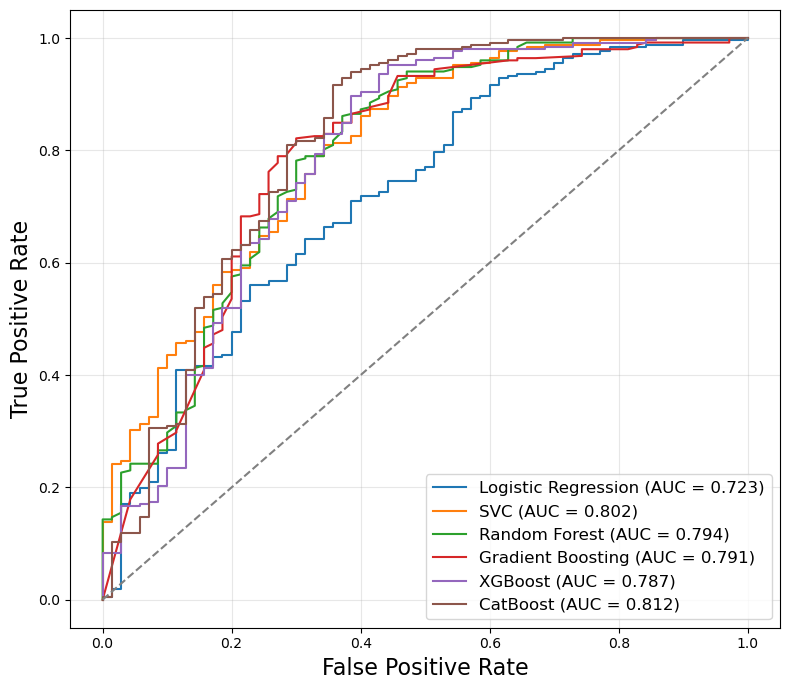


AUC per modello (desc):
- CatBoost: 0.8125
- SVC: 0.8015
- Random Forest: 0.7945
- Gradient Boosting: 0.7909
- XGBoost: 0.7869
- Logistic Regression: 0.7228


In [20]:
# ============================================================
# ROC curve (una figura) + AUC per tutti i classificatori
# (plug-and-play, da mettere nel MAIN)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def get_y_score(model, X):
    """
    Estrae uno score continuo per la ROC:
    - preferisce predict_proba[:,1]
    - altrimenti usa decision_function
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim != 2 or proba.shape[1] < 2:
            raise ValueError("predict_proba non ha 2 colonne (problema con classi/binario).")
        return proba[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        raise ValueError(f"{model.__class__.__name__} non supporta predict_proba né decision_function: ROC non calcolabile.")

# ------------------------------------------------------------
# IMPORTANTISSIMO:
# Assumo che nel tuo dataset la classe positiva sia y==1
# (es. {"0":"Cancer","1":"Healthy"} come nel tuo codice)
# Se invece vuoi considerare positiva la classe 0, dimmelo e ti dico la variante.
# ------------------------------------------------------------
POS_LABEL = 1

# ------------------------------------------------------------
# ASSUMO che questi modelli siano GIÀ stati creati e fittati nel main:
# model_lr, svc_model, rf, gb, xgb, cat_model
#
# NOTE:
# - Per SVC: se vuoi usare predict_proba, deve essere stato creato con probability=True
#   (altrimenti funzionerà comunque con decision_function, se disponibile).
# ------------------------------------------------------------
models = {
    "Logistic Regression": model_lr,
    "SVC": svc_model,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "CatBoost": cat_model
}

roc_results = {}

# Calcolo ROC + AUC per ciascun modello (senza sovrascrivere nulla)
for name, model in models.items():
    y_score = get_y_score(model, X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=POS_LABEL)
    auc_value = roc_auc_score(y_test, y_score)

    roc_results[name] = {
        "auc": float(auc_value),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "y_score": y_score
    }

# ------------------------------------------------------------
# Plot: una figura, una linea per modello
# ------------------------------------------------------------
plt.figure(figsize=(8, 7))

for name, roc in roc_results.items():
    plt.plot(roc["fpr"], roc["tpr"], label=f"{name} (AUC = {roc['auc']:.3f})")

# baseline casuale
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate", fontsize = 16)
plt.ylabel("True Positive Rate", fontsize = 16)
plt.title("", fontsize= 16)
plt.legend(loc="lower right", fontsize = 12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (Opzionale) stampo AUC ordinate
print("\nAUC per modello (desc):")
for name, roc in sorted(roc_results.items(), key=lambda x: x[1]["auc"], reverse=True):
    print(f"- {name}: {roc['auc']:.4f}")

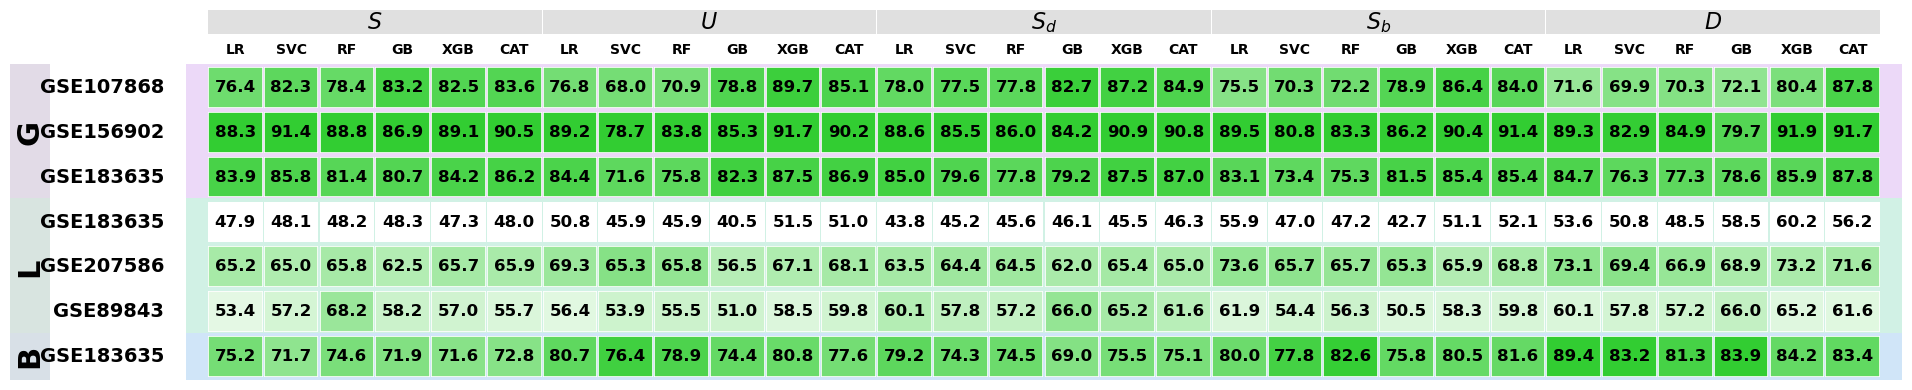

Figura salvata in: heatmap_1b.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

# =========================
# Helpers colori / gradienti
# =========================
def soft_gradient(base_color):
    return LinearSegmentedColormap.from_list("", ["#FFFFFF", base_color])

def mix_with_gray(color_hex, gray="#DDDDDD", factor=0.35):
    c = color_hex.lstrip("#")
    g = gray.lstrip("#")
    r1, g1, b1 = int(c[0:2], 16), int(c[2:4], 16), int(c[4:6], 16)
    r2, g2, b2 = int(g[0:2], 16), int(g[2:4], 16), int(g[4:6], 16)
    r  = int(r1 * (1 - factor) + r2 * factor)
    gg = int(g1 * (1 - factor) + g2 * factor)
    b  = int(b1 * (1 - factor) + b2 * factor)
    return f"#{r:02x}{gg:02x}{b:02x}"

# =========================
# FONT SIZES (modifica solo questi)
# =========================
FS_TUMOR   = 22   # titolo tumore (barra)
FS_DATASET = 14   # testo dataset dentro riga
FS_FS      = 16   # etichette FS in alto
FS_CELL    = 12   # numeri nelle celle
FS_CLF     = 10   # etichette classifier in alto (seconda riga header)

# =========================
# 1) LOAD + CLEAN (AUC.csv)
# =========================
path = "AUC.csv"
raw = pd.read_csv(path)

raw.columns = ["Tumor", "Dataset", "FS", "Classifier", "AUC"]
raw = raw[~((raw["AUC"] == "AUC") & (raw["Classifier"].isna()))].copy()
raw[["Tumor", "Dataset", "FS"]] = raw[["Tumor", "Dataset", "FS"]].ffill()
df = raw[raw["Classifier"].notna()].copy()

for c in ["Tumor", "Dataset", "FS", "Classifier"]:
    df[c] = df[c].astype(str).str.strip()

df["AUC"] = pd.to_numeric(df["AUC"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

# =========================
# 2) ORDINI
# =========================
tumor_order = ["GBM", "NSCLC", "BrCa"]

tumor_short = {"GBM": "G", "BrCa": "B", "NSCLC": "L"}

fs_order = ["S", "U", "Sd", "Sb", "D"]
fs_display = {
    "S":  r"$S$",
    "U":  r"$U$",
    "Sd": r"$S_d$",
    "Sb": r"$S_b$",
    "D":  r"$D$"
}
clf_order = ["LR", "SVC", "RF", "GB", "XGB", "CAT"]

df["Tumor"] = pd.Categorical(df["Tumor"], categories=tumor_order, ordered=True)
df["FS"] = pd.Categorical(df["FS"], categories=fs_order, ordered=True)
df["Classifier"] = pd.Categorical(df["Classifier"], categories=clf_order, ordered=True)

tumors = [t for t in tumor_order if t in df["Tumor"].dropna().unique().tolist()]
row_pairs = []
for t in tumors:
    ds_list = sorted(df.loc[df["Tumor"] == t, "Dataset"].dropna().unique().tolist())
    for ds in ds_list:
        row_pairs.append((t, ds))

# =========================
# 3) COLORI
# =========================
metric_color = "#3B82F6"  # AUC (blu vivo, luminoso)

tumor_bg = {
    "BrCa":  "#CDE8FF",
    "NSCLC": "#CFF7E8",
    "GBM":   "#F0D9FF",
}
tumor_start = {
    "BrCa":  "#F2FAFF",
    "NSCLC": "#F2FFFA",
    "GBM":   "#FBF2FF",
}
default_bg = "#F6F6F6"

FIG_BG_GRAY_FACTOR    = 0.2
TUMOR_BAR_GRAY_FACTOR = 0.7

# =========================
# 4) NORMALIZZAZIONE GLOBALE (AUC)
# =========================
vmin = float(df["AUC"].min(skipna=True)) if df["AUC"].notna().any() else 0.0
vmax = float(df["AUC"].max(skipna=True)) if df["AUC"].notna().any() else 1.0
if vmax == vmin:
    vmax = vmin + 1.0
norm = Normalize(vmin=vmin, vmax=vmax)

cmap_by_tumor = {t: soft_gradient(metric_color) for t in tumors}



# =========================
# 5) LAYOUT (NUOVO)
#    righe = (tumore,dataset)
#    colonne = (FS, Classifier) -> FS raggruppate, classifier dentro gruppo
# =========================
nrows = len(row_pairs)
ncols = len(fs_order) * len(clf_order)

# mappa indice colonna -> (fs, clf)
col_pairs = [(fs, clf) for fs in fs_order for clf in clf_order]


# =========================
# 4bis) NORMALIZZAZIONE PER COLONNA (FS x Classifier)
# =========================
col_minmax = {}
for (fs, clf) in col_pairs:
    vals = df.loc[(df["FS"] == fs) & (df["Classifier"] == clf), "AUC"].astype(float).values
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        col_minmax[(fs, clf)] = (0.0, 1.0)
    else:
        vmin_c = float(np.min(vals))
        vmax_c = float(np.max(vals))
        if vmax_c == vmin_c:
            vmax_c = vmin_c + 1e-6
        col_minmax[(fs, clf)] = (vmin_c, vmax_c)

fig_w = 0.65 * ncols + 2.5
fig_h = 0.85 * nrows + 2.2
fig = plt.figure(figsize=(fig_w, fig_h))
fig.patch.set_facecolor("white")

LEFT = 0.22
RIGHT = 0.98
#TOP = 0.84
#BOTTOM = 0.08

TOP = 0.70
BOTTOM = 0.32

gs = gridspec.GridSpec(
    nrows=nrows,
    ncols=ncols,
    wspace=0.02,
    hspace=0.10,
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)

axes = [[None]*ncols for _ in range(nrows)]
for i in range(nrows):
    for j in range(ncols):
        ax = fig.add_subplot(gs[i, j])
        axes[i][j] = ax
        ax.set_facecolor((1, 1, 1, 0))
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

# =========================
# 6) HEADER: FS (sopra, centrata sui gruppi) + Classifier (sopra ogni colonna)
# =========================
# --- FS header boxes (stile "tumor-like") ---
# --- FS header boxes + classifier row (2-tier header) ---
FS_BOX_H = 0.030          # altezza box FS
FS_BOX_Y_PAD = 0.040      # distanza tra top griglia e BOTTOM del box FS (crea spazio per classifier)
CLF_HDR_Y = 0.012         # distanza tra top griglia e testo classifier (deve stare < FS_BOX_Y_PAD)

FS_BOX_GRAY_FACTOR = 0.70
FS_BOX_BASE = "#E9E9E9"

top_row_bbox = [axes[0][j].get_position() for j in range(ncols)]

# FS headers (gruppi) CON BOX
for fs_i, fs in enumerate(fs_order):
    j0 = fs_i * len(clf_order)
    j1 = (fs_i + 1) * len(clf_order) - 1

    b0 = top_row_bbox[j0]
    b1 = top_row_bbox[j1]

    x0, x1 = b0.x0, b1.x1
    y_top = b0.y1

    # box dietro al titolo FS
    fig.patches.append(
        Rectangle(
            (x0, y_top + FS_BOX_Y_PAD),
            (x1 - x0),
            FS_BOX_H,
            transform=fig.transFigure,
            facecolor=mix_with_gray(FS_BOX_BASE, factor=FS_BOX_GRAY_FACTOR),
            edgecolor="none",
            zorder=-1
        )
    )

    # testo FS centrato dentro il box
    fig.text(
        (x0 + x1) / 2,
        y_top + FS_BOX_Y_PAD + FS_BOX_H / 2,
        fs_display.get(fs, fs),
        ha="center", va="center",
        fontsize=FS_FS, fontweight="bold", color="black"
    )

# Classifier headers (una per colonna)
# Classifier headers (sotto il box FS, sopra la griglia)
for j, (fs, clf) in enumerate(col_pairs):
    bbox = top_row_bbox[j]
    x_center = (bbox.x0 + bbox.x1) / 2
    y_top = bbox.y1  # top della griglia

    fig.text(
        x_center,
        y_top + CLF_HDR_Y,
        clf,
        ha="center", va="bottom",
        fontsize=FS_CLF, fontweight="bold", color="black"
    )

# =========================
# 7) Disegna celle: ogni cella = un valore AUC per (Tumor, Dataset, FS, Classifier)
# =========================
for i, (t, ds) in enumerate(row_pairs):
    cmap = cmap_by_tumor[t]
    for j, (fs, clf) in enumerate(col_pairs):
        ax = axes[i][j]
        sub = df[(df["Tumor"] == t) & (df["Dataset"] == ds) & (df["FS"] == fs) & (df["Classifier"] == clf)]

        # canvas cella singola
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.invert_yaxis()

        if sub.empty or sub["AUC"].isna().all():
            face = (0.95, 0.95, 0.95, 1.0)
            label = ""
        else:
            v = float(np.nanmean(sub["AUC"].values))

            vmin_c, vmax_c = col_minmax[(fs, clf)]
            norm_c = Normalize(vmin=vmin_c, vmax=vmax_c)

            v = float(np.clip(v, vmin_c, vmax_c))
            face = cmap(norm_c(v))
            label = f"{v:.1f}"

        ax.add_patch(Rectangle((0, 0), 1, 1,
                               facecolor=face, edgecolor="white", linewidth=1.2))
        ax.text(0.5, 0.5, label,
                ha="center", va="center",
                fontsize=FS_CELL, fontweight="bold", color="black",
                clip_on=True)

# =========================
# 8) Barre di riga: Tumore + Dataset a sinistra + sfondo gruppo tumore
# =========================
PAD_X = 0.01
PAD_Y = 0.004

tumor_to_rows = {}
for idx, (t, ds) in enumerate(row_pairs):
    tumor_to_rows.setdefault(t, []).append(idx)

for t in tumors:
    rows_t = tumor_to_rows.get(t, [])
    if not rows_t:
        continue

    r0, r1 = min(rows_t), max(rows_t)

    left_panel  = axes[r0][0].get_position().x0
    right_panel = axes[r0][-1].get_position().x1
    top_panel   = axes[r0][0].get_position().y1
    bottom_panel= axes[r1][0].get_position().y0

    bg_raw = tumor_bg.get(str(t), default_bg)
    bg = mix_with_gray(bg_raw, factor=FIG_BG_GRAY_FACTOR)

    panel_x0 = max(0.0, left_panel - PAD_X)
    panel_y0 = max(0.0, bottom_panel - PAD_Y)
    panel_w  = min(1.0, right_panel + PAD_X) - panel_x0
    panel_h  = min(1.0, top_panel + PAD_Y) - panel_y0

    fig.patches.append(
        Rectangle((panel_x0, panel_y0), panel_w, panel_h,
                  transform=fig.transFigure,
                  facecolor=bg, edgecolor="none",
                  zorder=-10)
    )

    bar_w = 0.018
    bar_x = panel_x0 - 0.08
    fig.patches.append(
        Rectangle((bar_x, panel_y0), bar_w, panel_h,
                  transform=fig.transFigure,
                  facecolor=mix_with_gray(bg_raw, factor=TUMOR_BAR_GRAY_FACTOR),
                  edgecolor="none",
                  zorder=-5)
    )
    fig.text(bar_x + bar_w/2, panel_y0 + panel_h/2, tumor_short.get(str(t), str(t)),
             ha="center", va="center",
             rotation=90,
             fontsize=FS_TUMOR, fontweight="bold", color="black")

# etichetta dataset per riga
for i, (t, ds) in enumerate(row_pairs):
    bbox = axes[i][0].get_position()
    y0, y1 = bbox.y0, bbox.y1
    x_text = bbox.x0 - 0.020
    fig.text(x_text, (y0+y1)/2, str(ds),
             ha="right", va="center",
             fontsize=FS_DATASET, fontweight="bold", color="black")

# =========================
# 9) Titolo
# =========================
#fig.text((LEFT + RIGHT)/2, TOP + 0.075,
#         "AUC heatmap (rows: Tumor/Dataset, columns: FS × Classifier)",
#         ha="center", va="bottom",
#         fontsize=14, fontweight="bold", color="black")

# =========================
# 10) SALVATAGGIO
# =========================
output_path = "heatmap_1b.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Figura salvata in: {output_path}")

# New Table